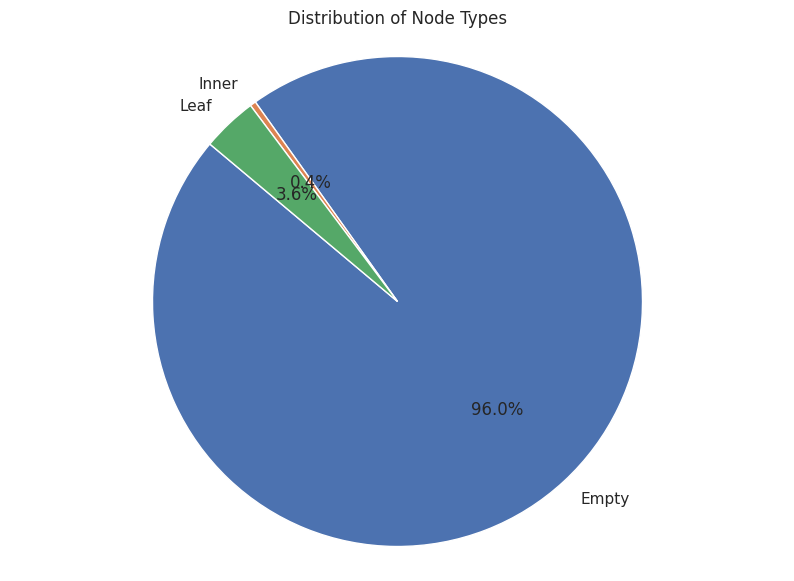

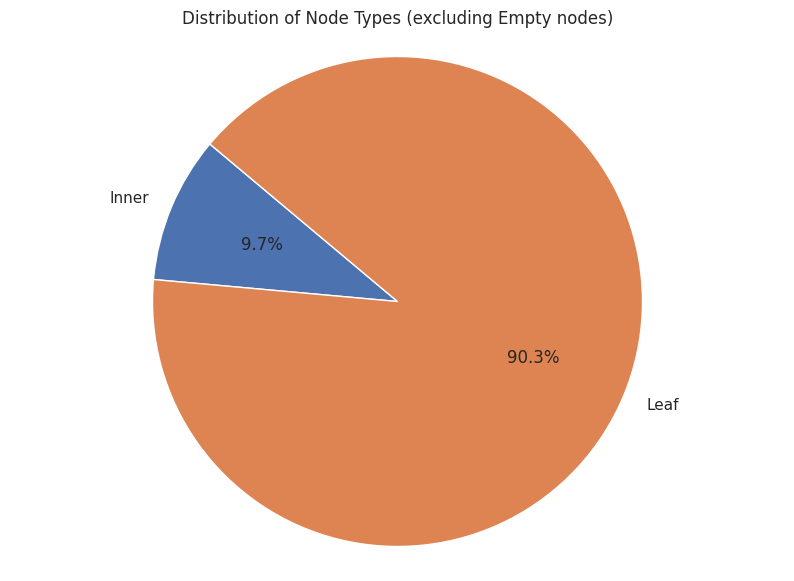

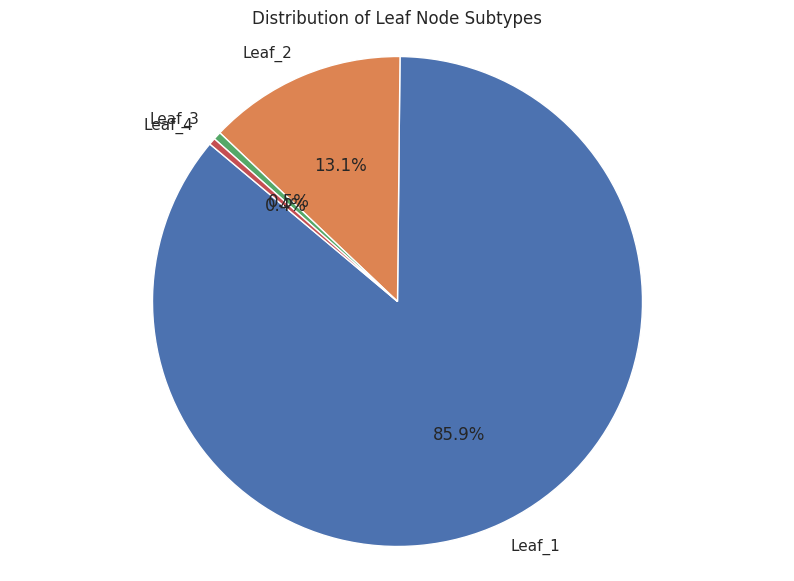

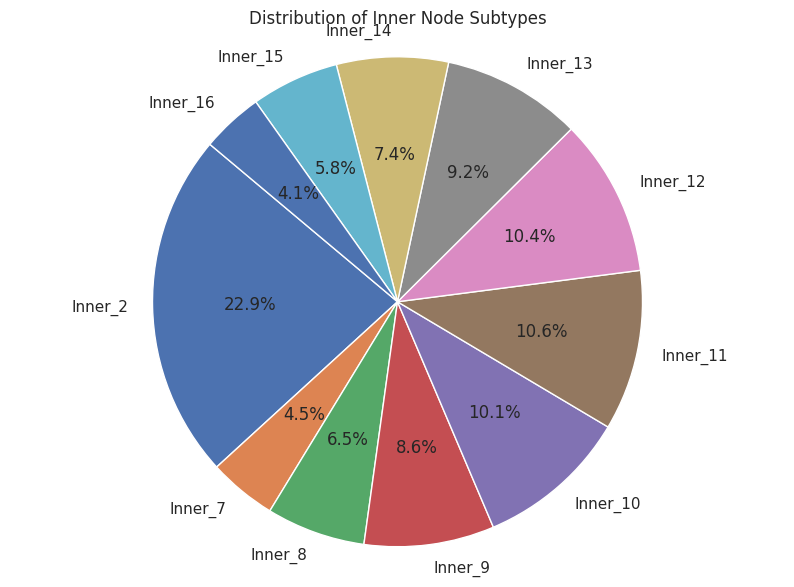

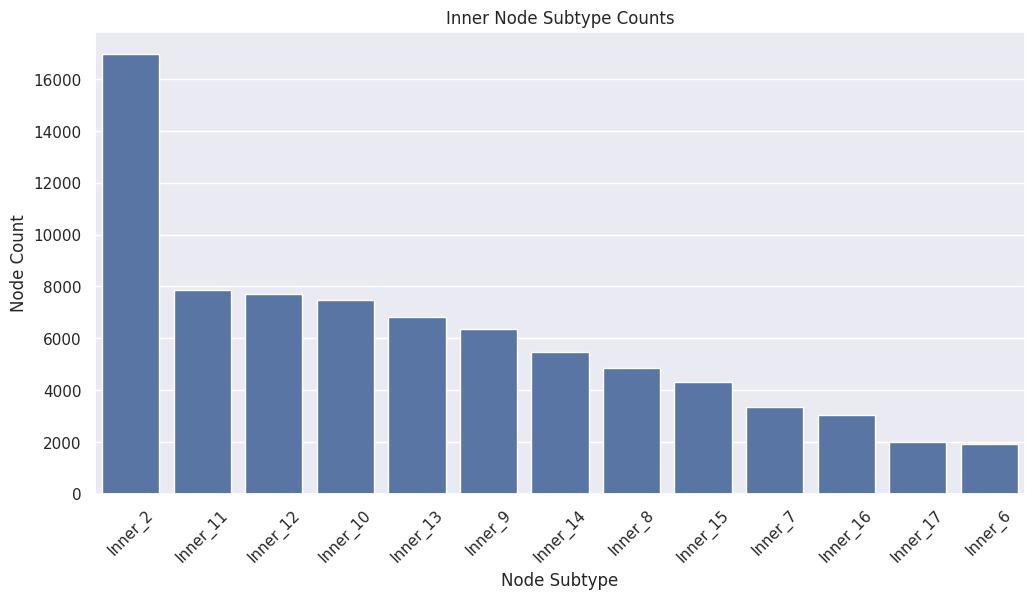

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

# Read the CSV file into a DataFrame
df = pd.read_csv('./carmen_stats_node_distribution.csv')

# Distribution of all node types
filtered_df = df[df['Node Type'] == df['Node Subtype']]
node_type_counts = filtered_df['Node Count']
plt.figure(figsize=(10, 7))
plt.pie(node_type_counts, labels=filtered_df['Node Type'], autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Node Types')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

# Distribution without empty nodes
df_non_empty = filtered_df[filtered_df['Node Type'] != 'Empty']
node_type_counts_non_empty = df_non_empty['Node Count']
plt.figure(figsize=(10, 7))
plt.pie(node_type_counts_non_empty, labels=df_non_empty['Node Type'], autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Node Types (excluding Empty nodes)')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

# Pie plot of node types for Leaf nodes (only if their number is within % of leaf nodes)
leaf_nodes_df = df[(df['Node Type'] == 'Leaf') & (df['Node Subtype'] != 'Leaf')]
leaf_node_count = leaf_nodes_df['Node Count'].sum()
leaf_nodes_df = leaf_nodes_df[leaf_nodes_df['Node Count'] / leaf_node_count >= 0.004]  # Filter subtypes with at least 0.4% of leaf nodes
plt.figure(figsize=(10, 7))
plt.pie(leaf_nodes_df['Node Count'], labels=leaf_nodes_df['Node Subtype'], autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Leaf Node Subtypes')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

# Pie plot of node types for Inner nodes (only if their number is within % of inner nodes)
inner_nodes_df = df[(df['Node Type'] == 'Inner') & (df['Node Subtype'] != 'Inner')]
inner_node_count = inner_nodes_df['Node Count'].sum()
inner_nodes_df = inner_nodes_df[inner_nodes_df['Node Count'] / inner_node_count >= 0.03]  # Filter subtypes with at least 3% of inner nodes
plt.figure(figsize=(10, 7))
plt.pie(inner_nodes_df['Node Count'], labels=inner_nodes_df['Node Subtype'], autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Inner Node Subtypes')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

# Bar plot of node count for Inner nodes (only if their number is within % of inner nodes)
inner_nodes_df = df[(df['Node Type'] == 'Inner') & (df['Node Subtype'] != 'Inner')]
inner_node_count = inner_nodes_df['Node Count'].sum()
inner_nodes_df = inner_nodes_df[inner_nodes_df['Node Count'] / inner_node_count >= 0.02]  # Filter subtypes with at least 2% of inner nodes
plt.figure(figsize=(12, 6))
sns.barplot(x='Node Subtype', y='Node Count', data=inner_nodes_df, order=inner_nodes_df.sort_values('Node Count', ascending=False)['Node Subtype'])
plt.title('Inner Node Subtype Counts')
plt.xticks(rotation=45)
plt.show()
